# **Anàlisi de les Pluges per Estació**

Aquest notebook analitza l'evolució mensual de les pluges a tres estacions meteorològiques:
- **Sabadell Centre**
- **Sabadell Nord (Parc Agrari)**
- **Vacarisses**

Per a cada estació es mostra:
1. L'evolució anual de la pluja per a cada mes (gràfic 4×3)
2. La mitjana mensual de pluja al llarg de tot el període
3. Una comparació final entre les tres estacions

## 1. Configuració i Funcions Auxiliars

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import warnings

warnings.filterwarnings('ignore')

month_names = {
    1: 'Gener', 2: 'Febrer', 3: 'Març', 4: 'Abril',
    5: 'Maig', 6: 'Juny', 7: 'Juliol', 8: 'Agost',
    9: 'Setembre', 10: 'Octubre', 11: 'Novembre', 12: 'Desembre'
}

In [2]:
def load_station_data(url):
    """Carrega les dades diàries d'una estació i afegeix columnes de temps."""
    df = pd.read_csv(url)
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    df['year'] = pd.to_datetime(df['date']).dt.year
    df['month'] = pd.to_datetime(df['date']).dt.month
    df['day'] = pd.to_datetime(df['date']).dt.day
    return df


def get_monthly_series(df):
    """Retorna un diccionari {mes: sèrie de pluja anual} per als 12 mesos."""
    monthly_totals = df.groupby(['year', 'month'])['rain_mm'].sum()
    return {m: monthly_totals.xs(m, level='month') for m in range(1, 13)}


def plot_monthly_grid(monthly_series, station_name):
    """Gràfic 4×3 amb l'evolució anual de la pluja per a cada mes."""
    fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharex=False)
    axes = axes.flatten()

    for i in range(12):
        ax = axes[i]
        data = monthly_series[i + 1]
        data.plot.bar(ax=ax, color='#2980b9')
        ax.set_title(month_names[i + 1], fontsize=12, fontweight='bold')
        ax.set_ylim(0, 200)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        mean_val = data.mean()
        ax.axhline(mean_val, color='red', linestyle='--', linewidth=1)
        ax.text(
            ax.get_xlim()[1],
            mean_val,
            f'{mean_val:.1f}',
            va='center',
            ha='left',
            fontsize=8,
            color='red',
        )

    fig.suptitle(f'Evolució Anual de Pluja — {station_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_monthly_average(df, station_name, period):
    """Gràfic de barres amb la mitjana mensual de pluja."""
    monthly_totals = df.groupby(['year', 'month'])['rain_mm'].sum()
    month_rain = monthly_totals.groupby('month').mean()
    month_rain.index = month_rain.index.map(month_names)

    fig, ax = plt.subplots(figsize=(10, 5))
    month_rain.plot.bar(ax=ax, color='#2980b9')
    # Afegir valors a les barres
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Mes', fontsize=12)
    ax.set_ylabel('Pluja (mm)', fontsize=12)
    ax.set_title(f'Mitjana Mensual de Pluja — {station_name} ({period})', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    return month_rain

## 2. Sabadell Centre

### 2.1 Càrrega de Dades

In [3]:
url_sbd_centre = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_Centre_daily.csv'
df_sbd_centre = load_station_data(url_sbd_centre)

print(f"Sabadell Centre: {df_sbd_centre['year'].min()}–{df_sbd_centre['year'].max()}")
print(f"Total registres: {len(df_sbd_centre):,}")

Sabadell Centre: 2008–2026
Total registres: 5,834


### 2.2 Evolució Anual per Mes

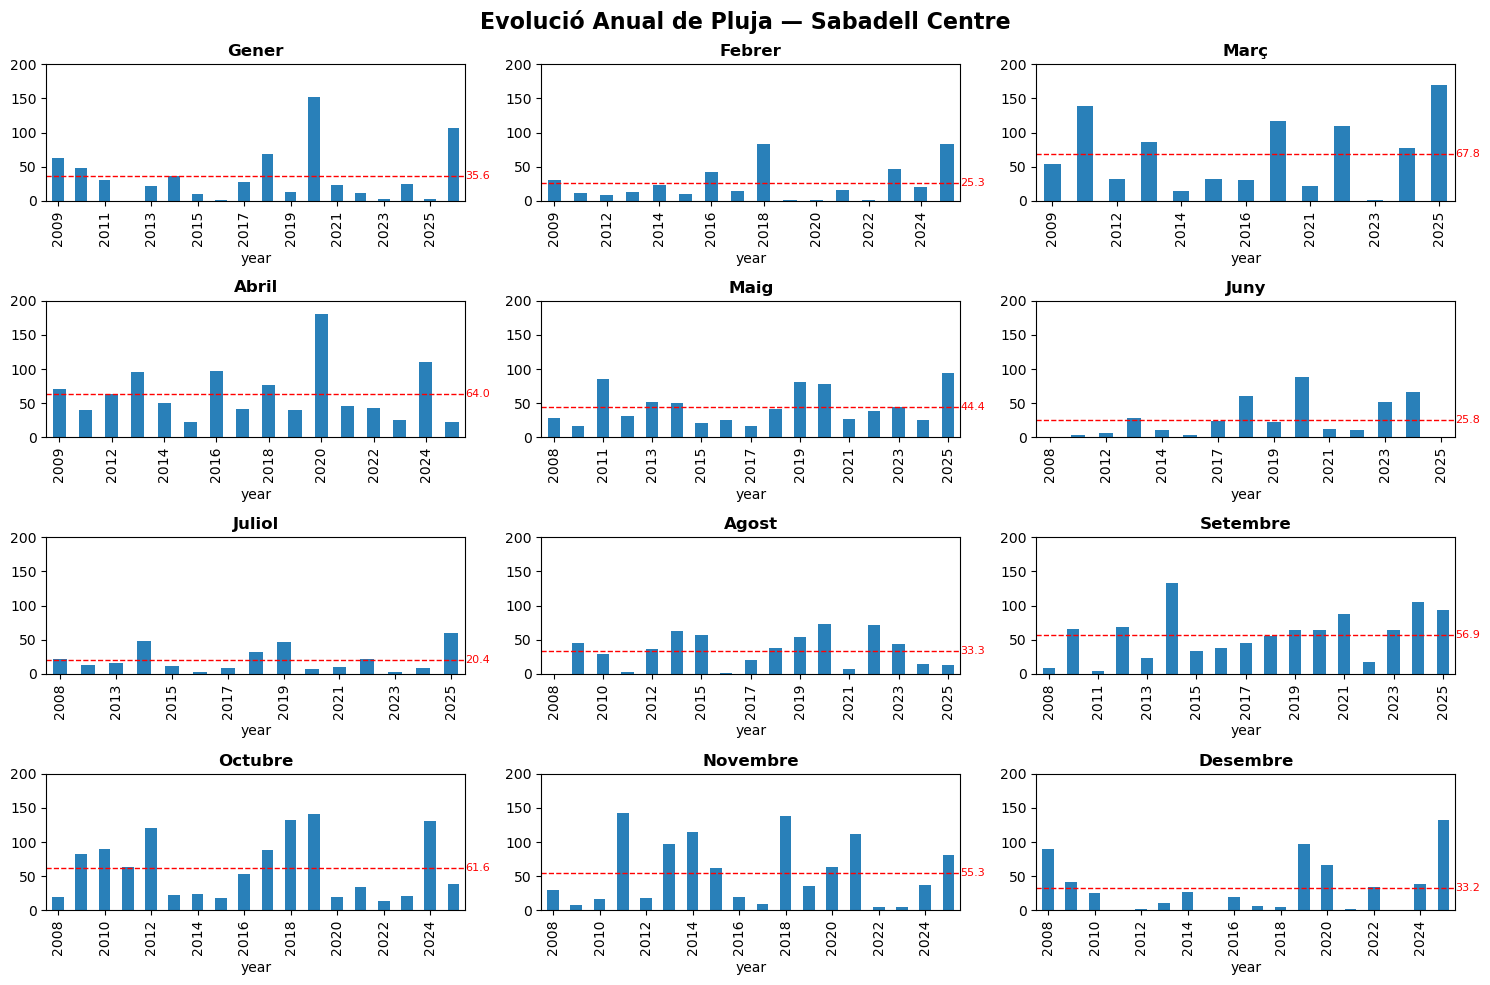

In [4]:
monthly_sbd_c = get_monthly_series(df_sbd_centre)
plot_monthly_grid(monthly_sbd_c, 'Sabadell Centre')

### 2.3 Mitjana Mensual de Pluja

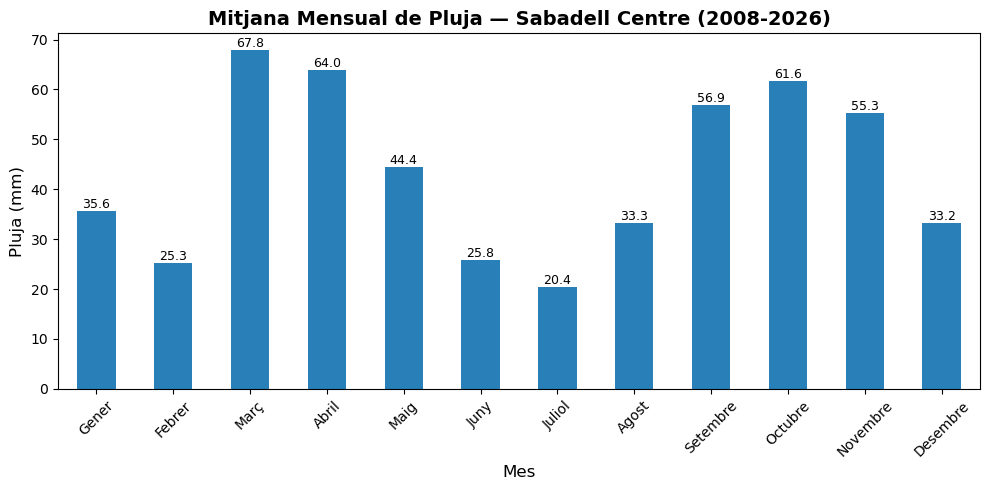

In [5]:
avg_sbd_c = plot_monthly_average(df_sbd_centre, 'Sabadell Centre', f"{df_sbd_centre['year'].min()}-{df_sbd_centre['year'].max()}")

## 3. Sabadell Nord (Parc Agrari)

### 3.1 Càrrega de Dades

In [6]:
url_sbd_nord = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_nord_daily.csv'
df_sbd_nord = load_station_data(url_sbd_nord)

print(f"Sabadell Nord: {df_sbd_nord['year'].min()}–{df_sbd_nord['year'].max()}")
print(f"Total registres: {len(df_sbd_nord):,}")

Sabadell Nord: 2008–2026
Total registres: 6,369


### 3.2 Evolució Anual per Mes

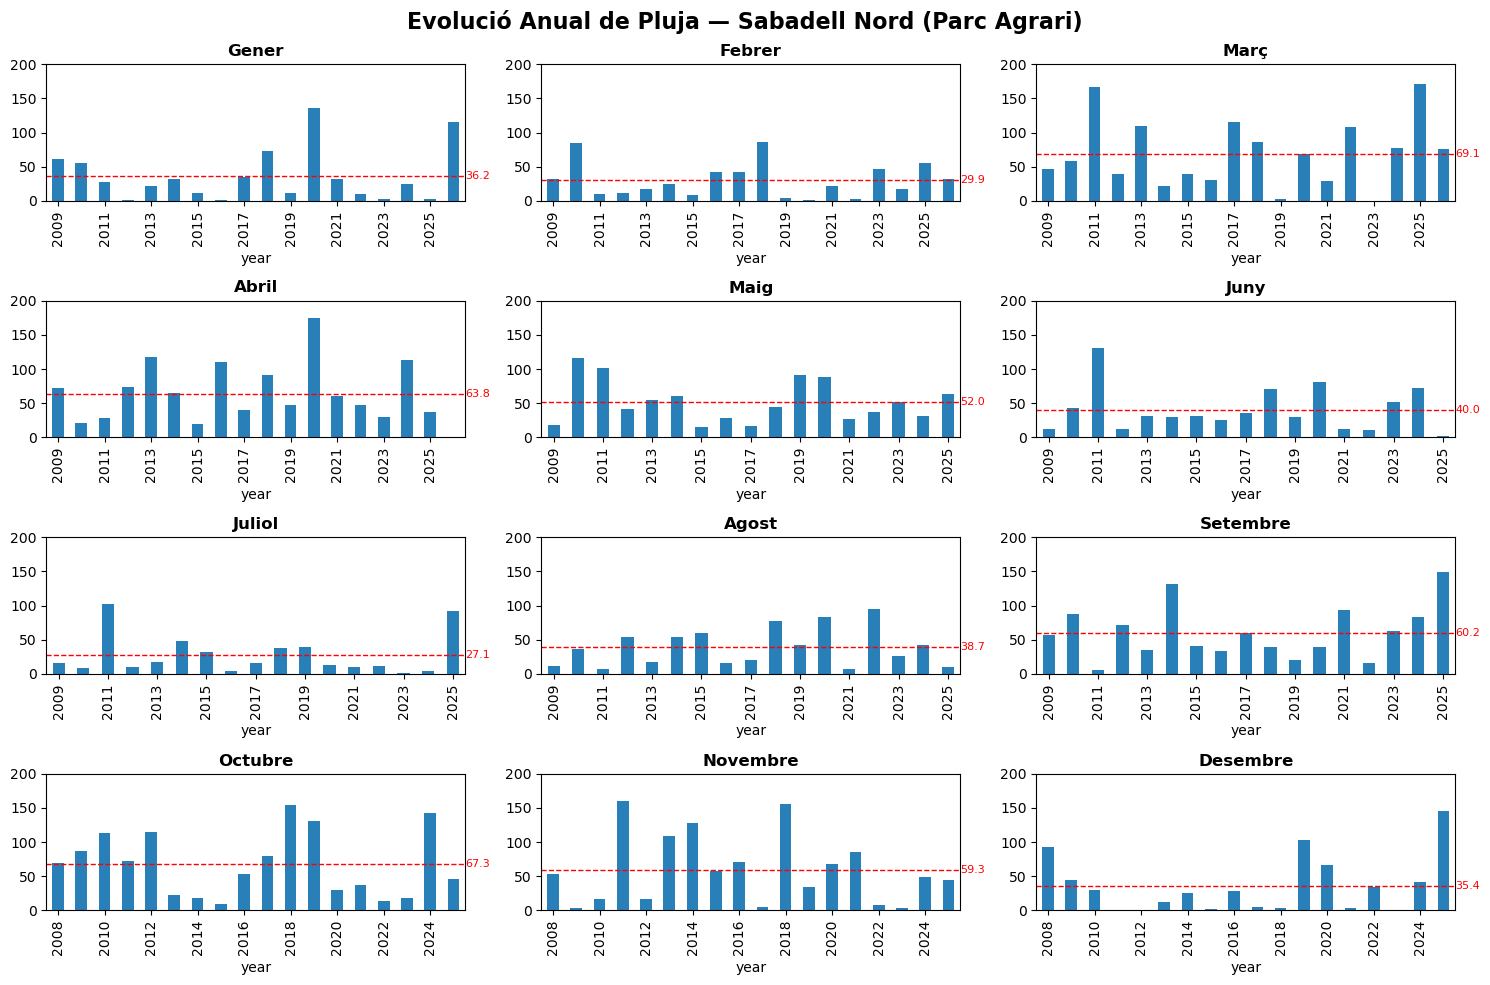

In [7]:
monthly_sbd_n = get_monthly_series(df_sbd_nord)
plot_monthly_grid(monthly_sbd_n, 'Sabadell Nord (Parc Agrari)')

### 3.3 Mitjana Mensual de Pluja

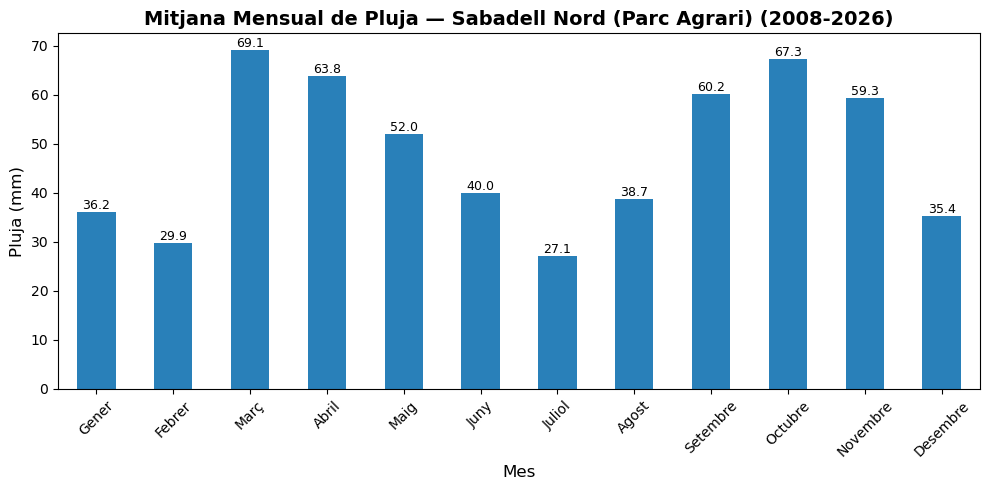

In [8]:
avg_sbd_n = plot_monthly_average(df_sbd_nord, 'Sabadell Nord (Parc Agrari)', f"{df_sbd_nord['year'].min()}-{df_sbd_nord['year'].max()}")

## 4. Vacarisses

### 4.1 Càrrega de Dades

In [9]:
url_vac = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Vacarisses_daily.csv'
df_vac = load_station_data(url_vac)

print(f"Vacarisses: {df_vac['year'].min()}–{df_vac['year'].max()}")
print(f"Total registres: {len(df_vac):,}")

Vacarisses: 1996–2026
Total registres: 10,960


### 4.2 Evolució Anual per Mes

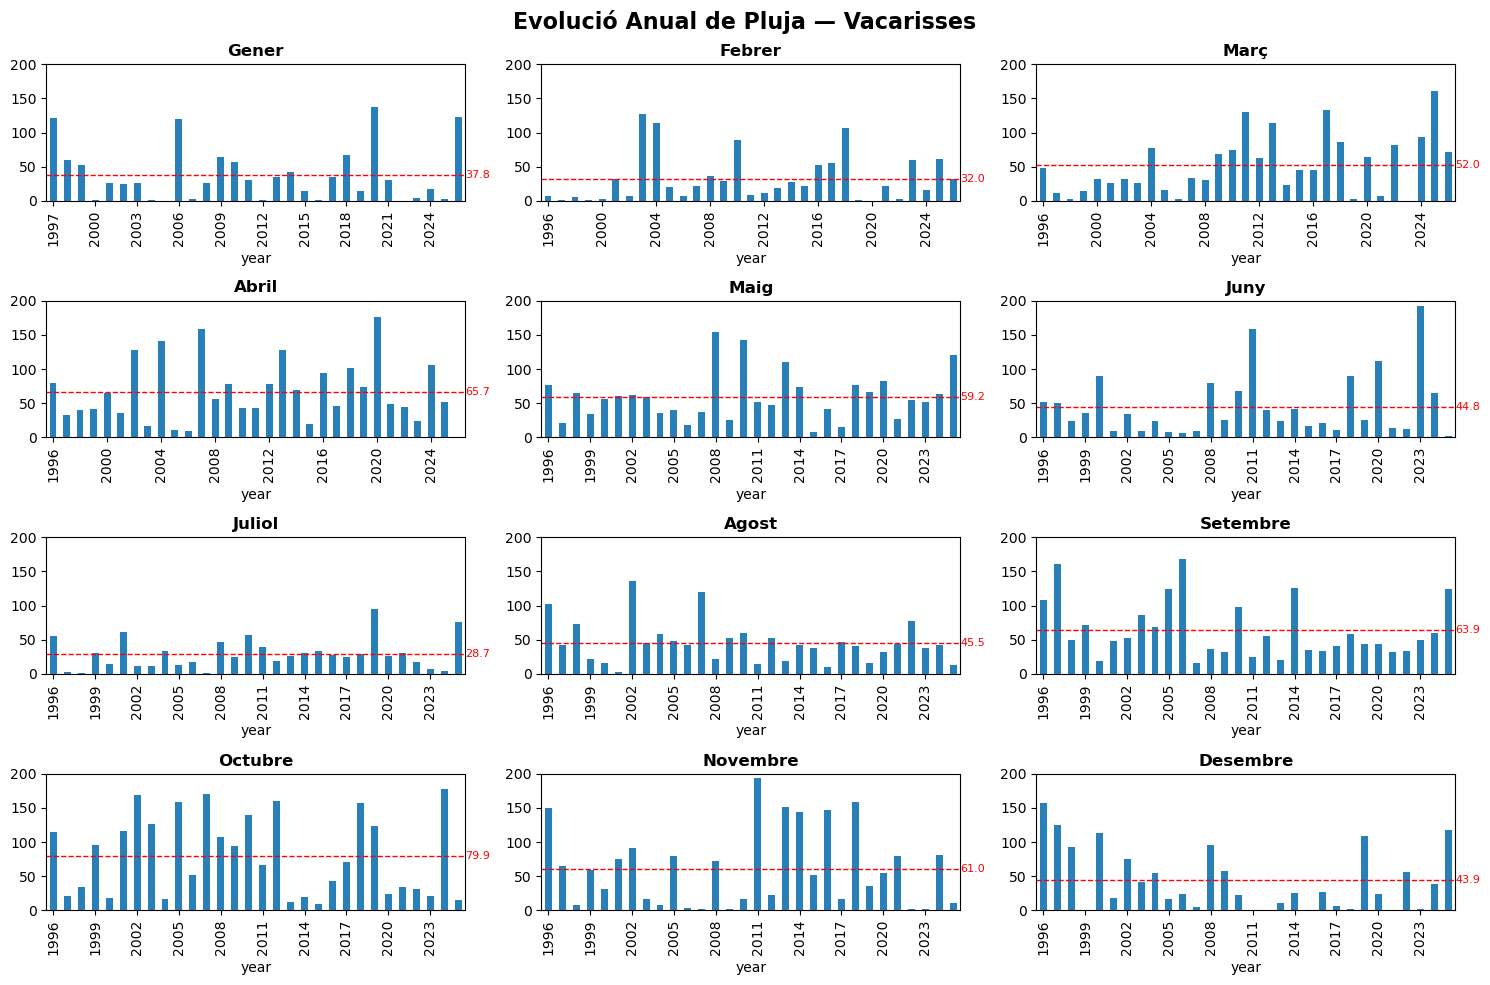

In [10]:
monthly_vac = get_monthly_series(df_vac)
plot_monthly_grid(monthly_vac, 'Vacarisses')

### 4.3 Mitjana Mensual de Pluja

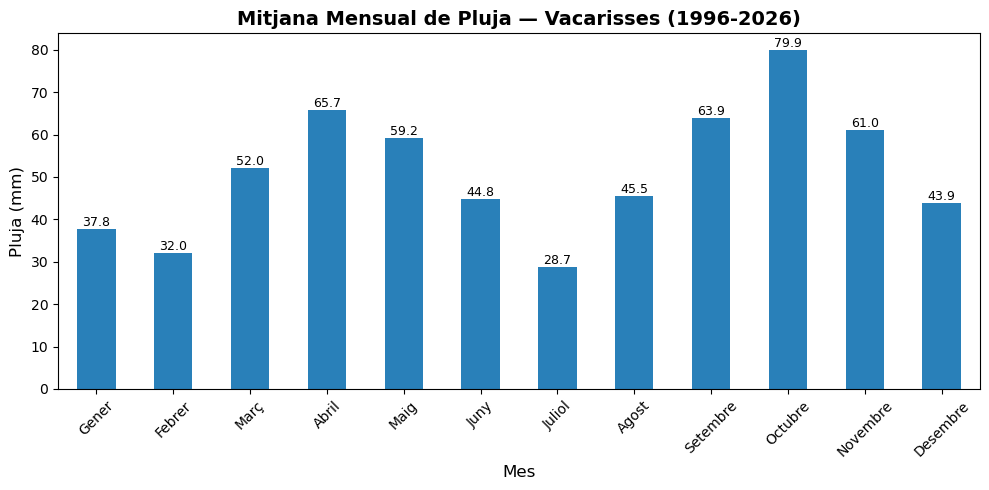

In [11]:
avg_vac = plot_monthly_average(df_vac, 'Vacarisses', f"{df_vac['year'].min()}-{df_vac['year'].max()}")

## 5. Comparació i Conclusions

### 5.1 Mesos Més Plujosos (Comparació)

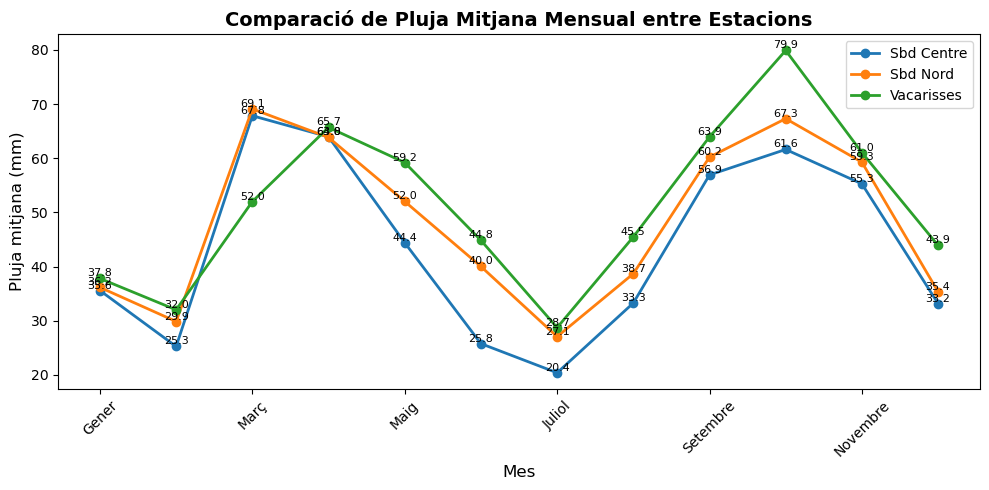

In [12]:
comparison = pd.DataFrame({
    'Sbd Centre': avg_sbd_c,
    'Sbd Nord': avg_sbd_n,
    'Vacarisses': avg_vac
})

fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot(ax=ax, marker='o', linewidth=2)
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Pluja mitjana (mm)', fontsize=12)
ax.set_title('Comparació de Pluja Mitjana Mensual entre Estacions', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')

# Afegir valors a les línies
for column in comparison.columns:
    for i, val in enumerate(comparison[column]):
        ax.text(i, val, f'{val:.1f}', fontsize=8, ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [13]:
print("\nMesos més plujosos per estació:")
for name, avg in [('Sabadell Centre', avg_sbd_c), ('Sabadell Nord', avg_sbd_n), ('Vacarisses', avg_vac)]:
    top3 = avg.nlargest(3)
    print(f"\n  {name}:")
    for month, val in top3.items():
        print(f"    {month}: {val:.1f} mm")


Mesos més plujosos per estació:

  Sabadell Centre:
    Març: 67.8 mm
    Abril: 64.0 mm
    Octubre: 61.6 mm

  Sabadell Nord:
    Març: 69.1 mm
    Octubre: 67.3 mm
    Abril: 63.8 mm

  Vacarisses:
    Octubre: 79.9 mm
    Abril: 65.7 mm
    Setembre: 63.9 mm


### 5.2 Conclusions

Segons els gràfics d'evolució anual, **no hi ha una tendència clara** d'augment o disminució de les pluges al llarg dels anys a cap de les tres estacions.

Tot i això, es pot observar que **hi ha mesos amb més pluja que altres** de manera consistent entre les tres estacions, indicant un patró estacional marcat.

In [13]:
# === Statistical trend analysis ===
import sys
sys.path.insert(0, r"C:\Users\David\Documents\VO project\VO-evolution\scripts")
from statistical_tests import (
    mk_analysis_series, mann_kendall, sens_slope, pettitt_test,
    seasonal_mann_kendall, print_mk_table
)
from scipy import stats
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


## 6. Trend Analysis — Statistical Tests

Mann-Kendall trend test, Sen's slope, and Pettitt change-point detection on monthly and annual rainfall series.

### 6.1 Seasonal Mann-Kendall (accounting for monthly seasonality)

In [14]:
# Seasonal Mann-Kendall on monthly rainfall
# This accounts for the seasonal cycle and tests for a monotonic trend
results_smk = []
for name, df in [('Sbd Centre', df_sbd_centre), ('Sbd Nord', df_sbd_nord), ('Vacarisses', df_vac)]:
    r = seasonal_mann_kendall(df, 'rain_mm', month_col='month', year_col='year')
    r['station'] = name
    results_smk.append(r)
    print(f"\n{'='*60}")
    print(f"  Seasonal Mann-Kendall — {name}")
    print(f"{'='*60}")
    print(f"  S_total = {r['S_total']:.1f}")
    print(f"  Z = {r['Z']:.4f}")
    print(f"  p-value = {r['p_value']:.4f}")
    print(f"  Trend: {r['trend']}")
    print(f"  Significant at alpha=0.05: {'YES' if r['p_value'] < 0.05 else 'NO'}")
    # Per-month detail
    print(f"\n  Per-month MK statistics:")
    for mr in r['monthly_results']:
        print(f"    Month {mr['month']:2d}: S = {mr['S']:+6.1f}, n = {mr['n']}")



  Seasonal Mann-Kendall — Sbd Centre
  S_total = 26851.0
  Z = 3.0382
  p-value = 0.0024
  Trend: increasing
  Significant at alpha=0.05: YES

  Per-month MK statistics:
    Month  1: S = -1153.0, n = 539
    Month  2: S = +3062.0, n = 437
    Month  3: S = +5121.0, n = 397
    Month  4: S = -3892.0, n = 478
    Month  5: S = +3480.0, n = 504
    Month  6: S = +2791.0, n = 421
    Month  7: S = +2762.0, n = 456
    Month  8: S = +4979.0, n = 480
    Month  9: S = +2732.0, n = 495
    Month 10: S = +3107.0, n = 549
    Month 11: S = +1807.0, n = 529
    Month 12: S = +2055.0, n = 549

  Seasonal Mann-Kendall — Sbd Nord
  S_total = 27142.0
  Z = 2.4629
  p-value = 0.0138
  Trend: increasing
  Significant at alpha=0.05: YES

  Per-month MK statistics:
    Month  1: S = +1109.0, n = 558
    Month  2: S = +3825.0, n = 508
    Month  3: S = +5064.0, n = 558
    Month  4: S = -5624.0, n = 511
    Month  5: S = +3569.0, n = 527
    Month  6: S = +1572.0, n = 510
    Month  7: S = +1169.0, n =

### 6.2 Mann-Kendall per Month (individual months)

In [15]:
# MK + Sen's slope for each month separately
month_names_en = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                  7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

for name, df in [('Sbd Centre', df_sbd_centre), ('Sbd Nord', df_sbd_nord), ('Vacarisses', df_vac)]:
    monthly = df.groupby(['year', 'month'])['rain_mm'].sum().reset_index()
    print(f"\n{'='*60}")
    print(f"  MK per Month — {name}")
    print(f"{'='*60}")
    month_results = []
    for m in range(1, 13):
        sub = monthly[monthly['month'] == m].sort_values('year')
        years = sub['year'].values
        vals = sub['rain_mm'].values
        r = mk_analysis_series(years, vals, f'  {month_names_en[m]}')
        month_results.append(r)
    print_mk_table(month_results)



  MK per Month — Sbd Centre
Label                                              tau   MK p-value      Slope Trend           Sig 0.05  CP year
----------------------------------------------------------------------------------------------------------------
  Jan                                          -0.0980     0.6009    -0.9333 no trend               N     2012
  Feb                                           0.1500     0.4503     0.5929 no trend               N     2023
  Mar                                          -0.0256     0.9524    -0.2708 no trend               N     2024
  Apr                                          -0.1167     0.5643    -1.7833 no trend               N     2021
  May                                           0.1324     0.4896     0.8138 no trend               N     2018
  Jun                                           0.3143     0.1142     2.4750 no trend               N     2017
  Jul                                          -0.1238     0.5590    -0.4000 no

### 6.3 Annual Rainfall Trend

In [16]:
# Annual rainfall totals
for name, df in [('Sbd Centre', df_sbd_centre), ('Sbd Nord', df_sbd_nord), ('Vacarisses', df_vac)]:
    annual = df.groupby('year')['rain_mm'].sum().reset_index()
    r = mk_analysis_series(annual['year'].values, annual['rain_mm'].values, f'Annual rainfall — {name}')
    print(f"\n{r['summary']}")



--- Annual rainfall — Sbd Centre ---
  Mann-Kendall tau = 0.1579, p = 0.3680 (no trend)
  Sen's slope = 11.4571 per year [-11.6000, 30.5222]
  Pettitt change point: index=9, year~2017, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no

--- Annual rainfall — Sbd Nord ---
  Mann-Kendall tau = -0.0292, p = 0.8903 (no trend)
  Sen's slope = -2.5286 per year [-23.7000, 28.0667]
  Pettitt change point: index=13, year~2021, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no

--- Annual rainfall — Vacarisses ---
  Mann-Kendall tau = -0.0538, p = 0.6858 (no trend)
  Sen's slope = -1.7167 per year [-9.3765, 7.4045]
  Pettitt change point: index=25, year~2021, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no


### 6.4 Pettitt Test on Annual Series

In [17]:
# Pettitt change-point on annual totals
print("\nPettitt change-point detection on annual rainfall:")
for name, df in [('Sbd Centre', df_sbd_centre), ('Sbd Nord', df_sbd_nord), ('Vacarisses', df_vac)]:
    annual = df.groupby('year')['rain_mm'].sum().reset_index()
    pt = pettitt_test(annual['rain_mm'].values)
    cp_year = annual['year'].values[int(pt['cp_index'])] if not np.isnan(pt['cp_index']) else 'N/A'
    print(f"  {name:15s}: CP at year {cp_year}, U={pt['U_stat']:.1f}, "
          f"p={pt['p_value']:.4f} {'*' if pt['significant_0.05'] else ''}")



Pettitt change-point detection on annual rainfall:
  Sbd Centre     : CP at year 2017, U=32.0, p=1.0000 
  Sbd Nord       : CP at year 2021, U=24.0, p=1.0000 
  Vacarisses     : CP at year 2021, U=68.0, p=1.0000 
